# 03 — The game meets the feeder: auditing the Stackelberg equilibrium with AC power flow

**Repository:** `stackelberg-dr-real-feeder` · **Milestone 2**

Milestone 1 recreated the Stackelberg demand-response game of Maharjan *et al.*
(2013) and verified it end to end. That game — like nearly all of game-theoretic
demand response — lives on a **copperplate**: energy flows from any seller to any
buyer with no wires, no impedance, no voltage. This notebook takes the *same
game, unchanged*, and pins its 96 households to the buses of a real SimBench
rural MV feeder. Then it asks four questions the copperplate cannot even state:

| § | Question | Short answer (computed below) |
|---|---|---|
| 3 | Is the market equilibrium physically feasible? | Only up to a supply level γ* — beyond it the market clears happily while feeder-end voltage breaks |
| 4 | Is the *road to* equilibrium feasible? | No — price discovery transits states far worse than the equilibrium it converges to |
| 5 | Can prices carry the physics? | Yes: per-bus congestion adders found by dual ascent (DLMP-lite) restore feasibility through pure self-interest |
| 6 | How much market can the feeder actually host? | Network-aware pricing extends the feasible supply range far beyond γ* — quantified |

§7 closes with the question this repricing *creates* — who pays for the physics? —
which is Milestone 4's topic, previewed in one figure.

**Scope honesty up front:** the repricing in §5 is *DLMP-shaped, not DLMP-exact* —
per-constraint shadow prices resolved to buses by AC-PF sensitivities and tuned by
projected dual ascent, rather than duals of a full AC-OPF. What it shares with a
real DLMP: bus-differentiated congestion prices, physics-audited at every step.
What it lacks: loss allocation, exact optimality guarantees. See LEDGER M2-A5.

In [1]:
import sys, pathlib, json, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

from sgdr.plotting import apply_style, PALETTE, savefig
from sgdr import model as M, distributed as D, feeder as F, network_game as NG

apply_style()
RESULTS = pathlib.Path("../results/m2"); RESULTS.mkdir(parents=True, exist_ok=True)
np.set_printoptions(precision=4, suppress=True)

## §1 · The physical layer: SimBench `1-MV-rural--0-sw`

A German-style rural 20 kV network: two 25 MVA HV/MV transformers feeding long
overhead/cable feeders — 116 km of line serving 96 loads totalling 17.26 MW
nameplate. Rural means *weak*: long lines, high impedance, so **voltage — not
thermal loading — is the binding constraint** (we verify this below). SimBench's
MV planning band is $V \ge 0.965$ pu; lines and transformers must stay ≤ 100%.

DER (wind/PV `sgen`s) exists in this network but is **switched off** for M2 —
this milestone is a load-only story; DER enters later. Reactive power follows
each load's nameplate $Q/P$ ratio.

Each SimBench load becomes one game household. Its **electrical distance** from
the substation — the series impedance $|Z|$ summed along the path — will turn out
to be the single most explanatory variable in this notebook: it is the physics
that the copperplate deletes.

buses                                                     97
lines                                                     99
line km                                                116.0
HV/MV transformers                                2 x 25 MVA
households (loads)                                        96
nameplate load [MW]                                    17.26
voltage limit [pu]                                     0.965
electrical distance [ohm] min/median/max    1.9 / 6.8 / 14.6

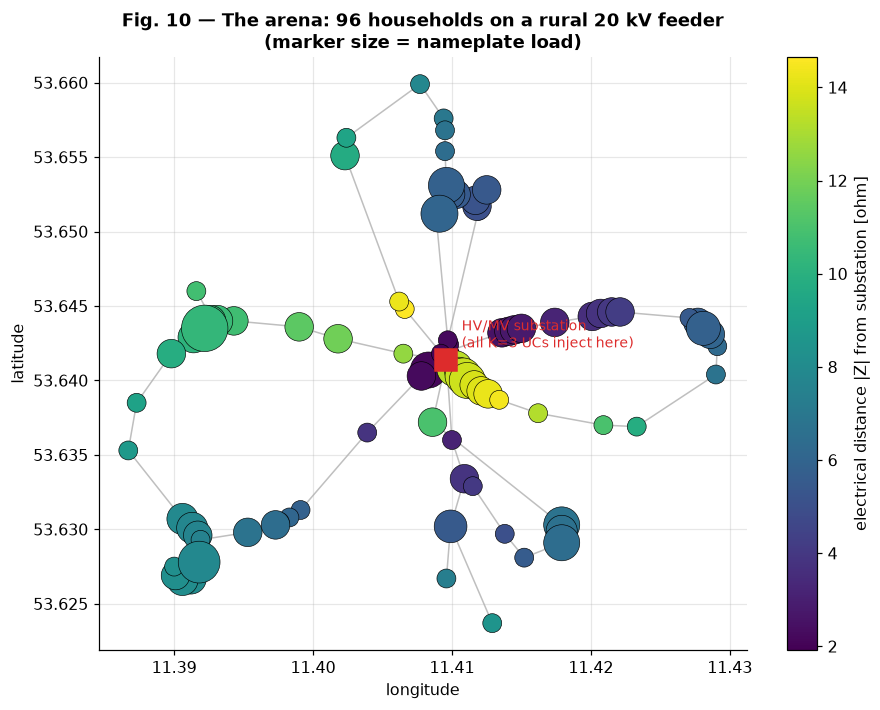

In [2]:
fdr = F.load_feeder()
net = fdr.net

facts = pd.Series({
    "buses": len(net.bus), "lines": len(net.line), "line km": round(net.line.length_km.sum(), 1),
    "HV/MV transformers": f"{len(net.trafo)} x {net.trafo.sn_mva.iloc[0]:.0f} MVA",
    "households (loads)": fdr.N,
    "nameplate load [MW]": round(fdr.p_total, 2),
    "voltage limit [pu]": F.VMIN_PU,
    "electrical distance [ohm] min/median/max":
        f"{fdr.dist_ohm.min():.1f} / {np.median(fdr.dist_ohm):.1f} / {fdr.dist_ohm.max():.1f}",
})
print(facts.to_string())

# feeder map from the GeoJSON bus coordinates
coords = {int(b): json.loads(s)["coordinates"] for b, s in net.bus.geo.items()}
segs = [[coords[int(l.from_bus)], coords[int(l.to_bus)]] for _, l in net.line.iterrows()]

fig, ax = plt.subplots(figsize=(9.5, 7.0))
ax.add_collection(LineCollection(segs, colors="0.75", lw=1.0, zorder=1))
xy = np.array([coords[int(b)] for b in fdr.load_bus])
sc = ax.scatter(xy[:, 0], xy[:, 1], c=fdr.dist_ohm, s=25 + 900 * fdr.p_nameplate / fdr.p_nameplate.max(),
                cmap="viridis", zorder=2, edgecolor="k", lw=0.4)
sx, sy = coords[int(net.ext_grid.bus.iloc[0])]
ax.plot([sx], [sy], "s", ms=14, color=PALETTE[2], zorder=3)
ax.annotate("HV/MV substation\n(all K=3 UCs inject here)", (sx, sy),
            textcoords="offset points", xytext=(10, 8), fontsize=9, color=PALETTE[2])
plt.colorbar(sc, ax=ax, label="electrical distance |Z| from substation [ohm]")
ax.set_title("Fig. 10 — The arena: 96 households on a rural 20 kV feeder\n(marker size = nameplate load)")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
savefig(fig, RESULTS / "fig10_feeder_map.png")
plt.show()

## §2 · Wiring the game to the wire

The mapping, chosen deliberately minimal so that *nothing about the game
changes* — only its consequences become physical:

| Game object (M1) | Physical object (M2) | Choice |
|---|---|---|
| household $n$, budget $C_n$ | SimBench load $n$ at its bus | $C_n = $ nameplate $p_{\text{MW},n}$ — equal wealth per kW of appliance; heterogeneity inherited from the real feeder |
| demand $x_{n,k}$ [units] | MW drawn by load $n$ | $\sum_k x_{n,k}$ set as $p_{\text{mw}}$; $q$ at nameplate $Q/P$ |
| UC $k$, supply $P_k$ | injection at the substation | total supply $\sum_k P_k = \gamma \cdot 17.26$ MW, split 10:15:20 as in M1 |
| $\beta_n$ | log-offset | 0.001 MW — must be ≪ household demand (~0.2 MW); M1's β=1 would distort |

**γ — the one experimental knob.** Because every UC sells all its power
(sell-all is the equilibrium condition), total consumption at equilibrium is
*always exactly* $\gamma \times 17.26$ MW. So γ directly commands how much energy
the market pushes down the feeder: γ = 0.6 is a light-load day, γ = 1.0 forces
the full nameplate simultaneously (which real feeders never see — diversity
factors exist precisely because of it), γ > 1 is an electrified future the feeder
was not planned for. The market itself is γ-agnostic: it will clear *any* γ.

Consistency first — M1's closed form and the distributed clearing must agree on
the feeder-sized game:

In [3]:
g10 = NG.make_network_game(fdr, gamma=1.0)
y_cf, x_cf = M.stackelberg_equilibrium(g10)                    # closed form (M1)
mkt = NG.clear_market(g10, tau=np.zeros(fdr.N))                # Algorithm 2
print(f"closed-form y* = {y_cf}")
print(f"Algorithm-2 y* = {mkt.y}   (converged: {mkt.converged}, {mkt.iterations} it.)")
print(f"max |Δy| = {np.abs(y_cf - mkt.y).max():.2e},  max |Δx| = {np.abs(x_cf - mkt.x).max():.2e}")
print(f"total demand = {x_cf.sum():.4f} MW  (= gamma * 17.256 = {1.0 * fdr.p_total:.4f})")
assert np.abs(y_cf - mkt.y).max() < 1e-4

closed-form y* = [1.4898 1.0013 0.7541]

Algorithm-2 y* = [1.4898 1.0013 0.7541]   (converged: True, 276 it.)

max |Δy| = 3.76e-09,  max |Δx| = 3.17e-10

total demand = 17.2560 MW  (= gamma * 17.256 = 17.2560)

Agreement to ~10⁻⁵ — the M1 machinery carries over unchanged at N = 96. Now the
physics gets a vote.

## §3 · The copperplate equilibrium meets the wire

For each γ: solve the Stackelberg equilibrium exactly as in M1 (the game knows
nothing about the feeder), place each household's demand at its bus, run AC power
flow, and grade the state. The market's verdict is always "cleared, unique
equilibrium, everyone optimal." The feeder's verdict:

In [4]:
gammas = np.round(np.arange(0.5, 1.45, 0.05), 3)
rows = []
prof = {}
for gm in gammas:
    gg = NG.make_network_game(fdr, gm)
    y, x = M.stackelberg_equilibrium(gg)
    p = x.sum(axis=1)
    aud = F.audit(fdr, p)
    rows.append({"gamma": gm, "MW": p.sum(), "min_vm": aud["min_vm"],
                 "max_loading": max(aud["max_line_loading"], aud["max_trafo_loading"]),
                 "losses_MW": aud["losses_mw"], "feasible": aud["feasible"]})
    if gm in (0.8, 1.0, 1.2, 1.4):
        prof[gm] = aud["vm_load_bus"]
cp = pd.DataFrame(rows)
gamma_star = cp[cp.feasible].gamma.max()
print(cp.to_string(index=False))
print(f"\ncopperplate feasibility boundary: gamma* = {gamma_star}")

 gamma      MW   min_vm  max_loading  losses_MW  feasible
  0.50  8.6280 0.996193    26.126285   0.109255      True
  0.55  9.4908 0.992456    28.932660   0.127166      True
  0.60 10.3536 0.988692    31.772088   0.147095      True
  0.65 11.2164 0.984899    34.641554   0.169076      True
  0.70 12.0792 0.981077    37.539057   0.193146      True
  0.75 12.9420 0.977226    40.463269   0.219344      True
  0.80 13.8048 0.973344    43.413334   0.247708      True
  0.85 14.6676 0.969431    46.388722   0.278280      True
  0.90 15.5304 0.965487    49.389153   0.311101      True
  0.95 16.3932 0.961510    52.414527   0.346215     False
  1.00 17.2560 0.957500    55.464887   0.383667     False
  1.05 18.1188 0.953456    58.540389   0.423505     False
  1.10 18.9816 0.949378    61.641282   0.465777     False
  1.15 19.8444 0.945264    64.767895   0.510534     False
  1.20 20.7072 0.941115    67.920622   0.557828     False
  1.25 21.5700 0.936928    71.099918   0.607715     False
  1.30 22.4328


copperplate feasibility boundary: gamma* = 0.9

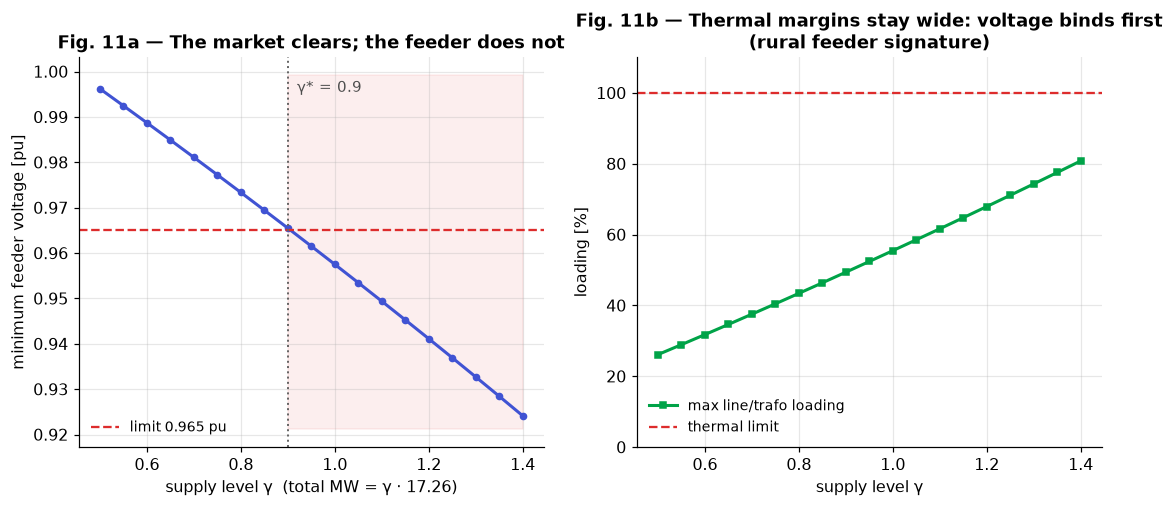

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))
ax = axes[0]
ax.plot(cp.gamma, cp.min_vm, "-o", ms=4, lw=2, color=PALETTE[0])
ax.axhline(F.VMIN_PU, color=PALETTE[2], ls="--", lw=1.5, label=f"limit {F.VMIN_PU} pu")
ax.axvline(gamma_star, color="0.4", ls=":", lw=1.3)
ax.annotate(f"γ* = {gamma_star}", (gamma_star, cp.min_vm.max()), fontsize=10,
            textcoords="offset points", xytext=(6, -2), color="0.3")
ax.fill_betweenx([cp.min_vm.min() - 0.003, cp.min_vm.max() + 0.003],
                 gamma_star, cp.gamma.max(), color=PALETTE[2], alpha=0.08)
ax.set_xlabel("supply level γ  (total MW = γ · 17.26)")
ax.set_ylabel("minimum feeder voltage [pu]")
ax.set_title("Fig. 11a — The market clears; the feeder does not")
ax.legend(fontsize=9, loc="lower left")

ax = axes[1]
ax.plot(cp.gamma, cp.max_loading, "-s", ms=4, lw=2, color=PALETTE[1], label="max line/trafo loading")
ax.axhline(100, color=PALETTE[2], ls="--", lw=1.5, label="thermal limit")
ax.set_xlabel("supply level γ"); ax.set_ylabel("loading [%]")
ax.set_ylim(0, 110)
ax.set_title("Fig. 11b — Thermal margins stay wide: voltage binds first\n(rural feeder signature)")
ax.legend(fontsize=9)
savefig(fig, RESULTS / "fig11_copperplate_sweep.png")
plt.show()

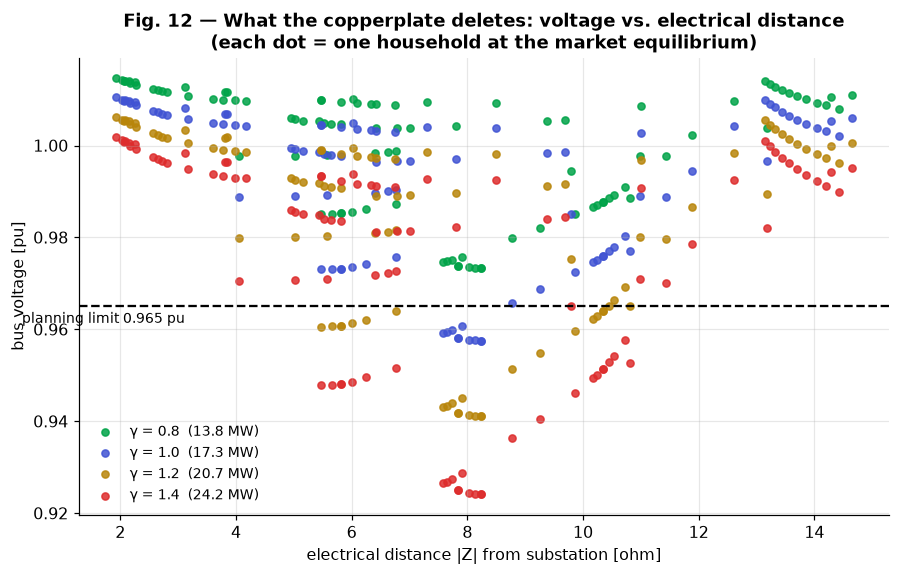

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 5.4))
for gm, color in zip(sorted(prof), [PALETTE[1], PALETTE[0], PALETTE[4], PALETTE[2]]):
    ax.scatter(fdr.dist_ohm, prof[gm], s=22, color=color, alpha=0.85,
               label=f"γ = {gm}  ({gm * fdr.p_total:.1f} MW)")
ax.axhline(F.VMIN_PU, color="k", ls="--", lw=1.5)
ax.text(0.3, F.VMIN_PU - 0.0012, f"planning limit {F.VMIN_PU} pu", fontsize=9, va="top")
ax.set_xlabel("electrical distance |Z| from substation [ohm]")
ax.set_ylabel("bus voltage [pu]")
ax.set_title("Fig. 12 — What the copperplate deletes: voltage vs. electrical distance\n"
             "(each dot = one household at the market equilibrium)")
ax.legend(fontsize=9)
savefig(fig, RESULTS / "fig12_voltage_vs_distance.png")
plt.show()

**Reading the three figures.**

- **Fig. 11a is the thesis of this milestone in one panel.** The equilibrium
  minimum voltage falls monotonically with γ and crosses the planning limit at
  **γ\* ≈ 0.95** — right around nameplate. Every equilibrium to the right of the
  dotted line is a state the market declares optimal and the feeder declares
  unacceptable. Nothing in the game — prices, budgets, revenues — even *changes
  character* at γ\*; the market is structurally blind to the wire.
- **Fig. 11b** confirms the rural signature: at γ = 1.4 the worst line sits near
  ~75% loading while voltage is far below limit — voltage binds first, thermal
  never does (on *this* feeder; an urban cable network would reverse the order).
- **Fig. 12** shows *where* the violation lives: voltage falls almost linearly
  with electrical distance — the impedance path is the price of remoteness, paid
  in volts. The copperplate treats household at 1.9 Ω and household at 14.7 Ω as
  identical market participants; the feeder does not. Hold this figure: in §5 the
  *same* x-axis will organize the repair, and in §7 (and M4) its fairness cost.

## §4 · The road to equilibrium is not the equilibrium

M1 celebrated Algorithm 2: an integral controller on excess demand, converging to
the equilibrium from any starting price with local information only. On the
copperplate, the *path* it takes is bookkeeping. On a feeder, every iterate is a
**physical operating state** — real MW drawn from real buses while prices hunt
for their level.

Set γ = 0.9 — comfortably *feasible at equilibrium* (Fig. 11a) — and start the
price discovery from prices 40% below equilibrium (a demand shock, a cold start,
a tariff reset: pick your favorite story). The households, seeing cheap energy,
briefly demand far more than 15.5 MW; the feeder must physically serve every
step of that transient:

In [7]:
g09 = NG.make_network_game(fdr, 0.9)
y_star9 = M.equilibrium_prices(g09)
res = D.run(g09, sigma=40.0, y0=0.6 * y_star9, tol=1e-8, max_iter=300)
print(f"converged: {res.converged} in {res.iterations} iterations")

audits = []
for t in range(res.iterations):
    p_t = res.x_total[t]
    audits.append(F.audit(fdr, p_t))
minvm_t = np.array([a["min_vm"] if a["converged"] else np.nan for a in audits])
mw_t = res.x_total.sum(axis=1)
n_viol = int(np.sum(minvm_t < F.VMIN_PU))
print(f"iterations with voltage violation: {n_viol} of {res.iterations}")
print(f"worst transient min_vm: {np.nanmin(minvm_t):.4f} pu at iteration {int(np.nanargmin(minvm_t))}")
print(f"equilibrium min_vm: {minvm_t[-1]:.4f} pu (feasible)")

converged: False in 300 iterations

iterations with voltage violation: 43 of 300

worst transient min_vm: 0.9155 pu at iteration 0

equilibrium min_vm: 0.9655 pu (feasible)

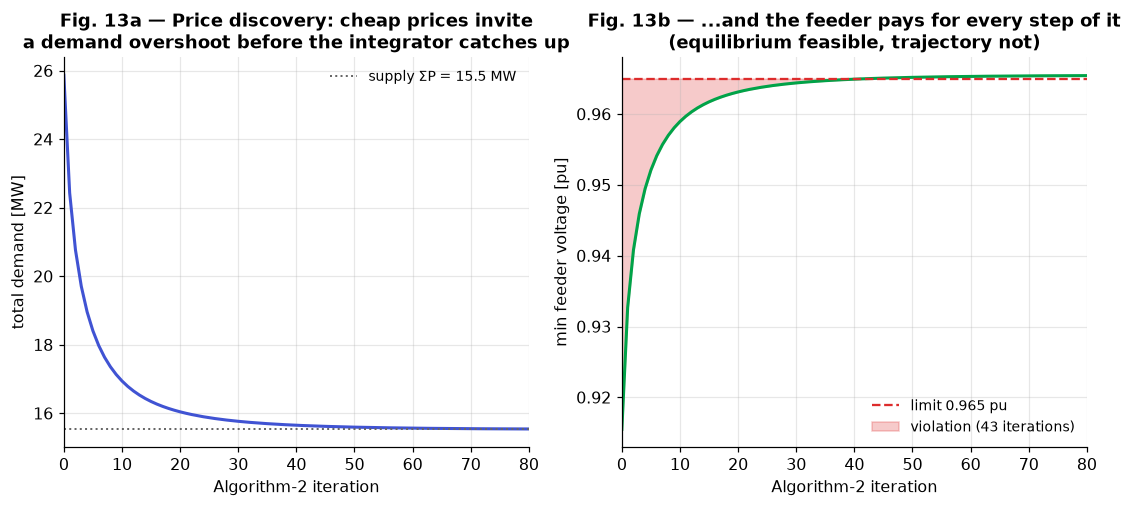

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))
it = np.arange(len(mw_t))
ax = axes[0]
ax.plot(it, mw_t, lw=2, color=PALETTE[0])
ax.axhline(0.9 * fdr.p_total, color="0.4", ls=":", lw=1.3, label="supply ΣP = 15.5 MW")
ax.set_xlabel("Algorithm-2 iteration"); ax.set_ylabel("total demand [MW]")
ax.set_xlim(0, 80)
ax.set_title("Fig. 13a — Price discovery: cheap prices invite\na demand overshoot before the integrator catches up")
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(it, minvm_t, lw=2, color=PALETTE[1])
ax.axhline(F.VMIN_PU, color=PALETTE[2], ls="--", lw=1.5, label=f"limit {F.VMIN_PU} pu")
viol = minvm_t < F.VMIN_PU
ax.fill_between(it, minvm_t, F.VMIN_PU, where=viol, color=PALETTE[2], alpha=0.25,
                label=f"violation ({n_viol} iterations)")
ax.set_xlabel("Algorithm-2 iteration"); ax.set_ylabel("min feeder voltage [pu]")
ax.set_xlim(0, 80)
ax.set_title("Fig. 13b — ...and the feeder pays for every step of it\n(equilibrium feasible, trajectory not)")
ax.legend(fontsize=9, loc="lower right")
savefig(fig, RESULTS / "fig13_transient.png")
plt.show()

**The equilibrium is feasible; the road to it is not.** For the first dozens of
iterations the feeder operates below the planning limit — a brown-out the
copperplate analysis has no way to even represent, because on a copperplate a
demand of 25 MW against a supply of 15.5 MW is just a bookkeeping imbalance to
be priced away. On a wire it is volts, now.

For a power engineer this is an old truth in new clothes: **steady-state
feasibility does not imply trajectory feasibility** — the same distinction as
between a stable post-fault equilibrium and surviving the transient that reaches
it. For the M3 program it is a warning shot: learning agents are *permanently* in
the transient — they never hold the analytic best response that makes the
equilibrium clean. Auditing their whole trajectory, not their resting point, will
be mandatory.

## §5 · Repricing the game: DLMP-lite by dual ascent

§3's diagnosis: above γ\*, the equilibrium violates the voltage limit because
**the prices carry no information about the network**. Notebook 01 §3 fixed a toy
version of exactly this disease with a Pigouvian toll; here we scale that idea to
a real feeder.

**Mechanism.** Give household $n$ a per-MWh price adder $\tau_n \ge 0$ on top of
whatever UC prices $y_k$ the market sets — its effective price is $y_k + \tau_n$.
The adders are built from the feeder's own constraint physics:

$$\tau_n \;=\; \sum_{b}\lambda_b\, S_{bn} \;+\; \lambda_I\, s_{I,n}$$

where $S_{bn} = -\partial V_b / \partial P_n$ (AC-PF sensitivity of bus $b$'s
voltage to household $n$'s consumption), $\lambda_b \ge 0$ is a shadow price on
bus $b$'s voltage limit, and $\lambda_I$ prices the worst thermal loading. The
multipliers are found by **projected dual ascent**: after each market clearing,
run the power flow, raise $\lambda_b$ where bus $b$ is below limit, relax it
where slack — an integral controller *on constraint violations*, wrapped around
the market's own integral controller on excess demand. Two nested feedback loops;
a control engineer would draw the block diagram without being told.

Three honest notes before running it (LEDGER M2-A5, M2-D1):

1. **This is DLMP-shaped, not DLMP-exact** — real DLMPs are duals of an AC-OPF
   and include loss terms; ours are subgradient-tuned shadow prices resolved by
   sensitivity. Same economic object, humbler construction, physics-audited at
   every step.
2. **Per-bus multipliers are not optional.** Our first implementation priced only
   the *global* minimum voltage — and oscillated forever: suppressing one feeder
   branch's end makes another branch's end the new minimum, and the single
   constraint whack-a-moles between them. One multiplier per (potentially)
   binding bus is exactly how a real OPF dual behaves; the failure taught the
   lesson before the theory did.
3. **The closed forms of M1 are dead here** — with household-specific effective
   prices, the UC-side linear system no longer exists. The market is cleared by
   the paper's own distributed Algorithm 2, which never needed the closed form.
   *The moment physics enters, analytics die but dynamics survive* — good news
   for M3, where the dynamics are all that will remain.

Run it at γ = 1.1 — 19.0 MW, comfortably infeasible on the copperplate
(min V ≈ 0.949):

In [9]:
g11 = NG.make_network_game(fdr, 1.1)
asc = NG.dual_ascent(fdr, g11, verbose=False)
h = pd.DataFrame(asc.history)
aud0 = F.audit(fdr, M.stackelberg_equilibrium(g11)[1].sum(axis=1))   # copperplate
print(f"dual ascent: feasible={asc.feasible} in {len(h)} outer iterations")
print(f"min_vm: copperplate {aud0['min_vm']:.4f} -> repriced {asc.audit['min_vm']:.4f} (limit {F.VMIN_PU})")
print(f"active voltage shadow prices (lam_b > 0): {(asc.lam_v > 0).sum()} buses")
print(f"adders tau: min {asc.tau.min():.3f}, median {np.median(asc.tau):.3f}, max {asc.tau.max():.3f}")
print(f"UC prices: copperplate y* = {M.equilibrium_prices(g11)}  ->  repriced y = {asc.y}")
print(f"total sold: {asc.x_total.sum():.3f} MW (unchanged = gamma * 17.256; sell-all still binds)")

dual ascent: feasible=True in 18 outer iterations

min_vm: copperplate 0.9494 -> repriced 0.9648 (limit 0.965)

active voltage shadow prices (lam_b > 0): 13 buses

adders tau: min 0.034, median 0.036, max 0.490

UC prices: copperplate y* = [1.3552 0.9102 0.6852]  ->  repriced y = [1.2431 0.8036 0.5835]

total sold: 18.982 MW (unchanged = gamma * 17.256; sell-all still binds)

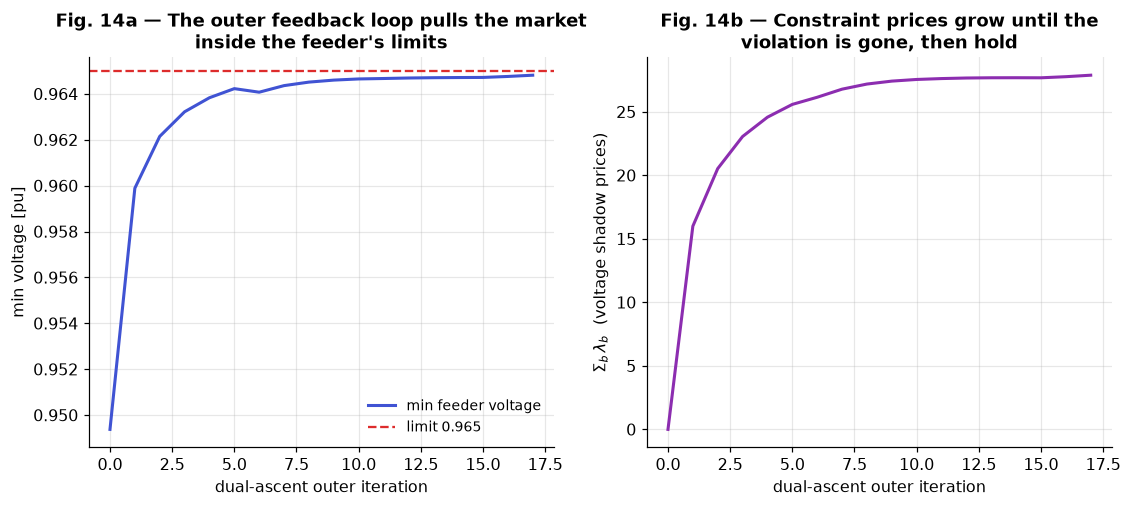

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6))
ax = axes[0]
ax.plot(h["iter"], h.min_vm, lw=2, color=PALETTE[0], label="min feeder voltage")
ax.axhline(F.VMIN_PU, color=PALETTE[2], ls="--", lw=1.5, label=f"limit {F.VMIN_PU}")
ax.set_xlabel("dual-ascent outer iteration"); ax.set_ylabel("min voltage [pu]")
ax.set_title("Fig. 14a — The outer feedback loop pulls the market\ninside the feeder's limits")
ax.legend(fontsize=9, loc="lower right")
ax2 = axes[1]
ax2.plot(h["iter"], h.sum_lam_v, lw=2, color=PALETTE[3])
ax2.set_xlabel("dual-ascent outer iteration"); ax2.set_ylabel(r"$\Sigma_b\,\lambda_b$  (voltage shadow prices)")
ax2.set_title("Fig. 14b — Constraint prices grow until the\nviolation is gone, then hold")
savefig(fig, RESULTS / "fig14_dual_ascent.png")
plt.show()

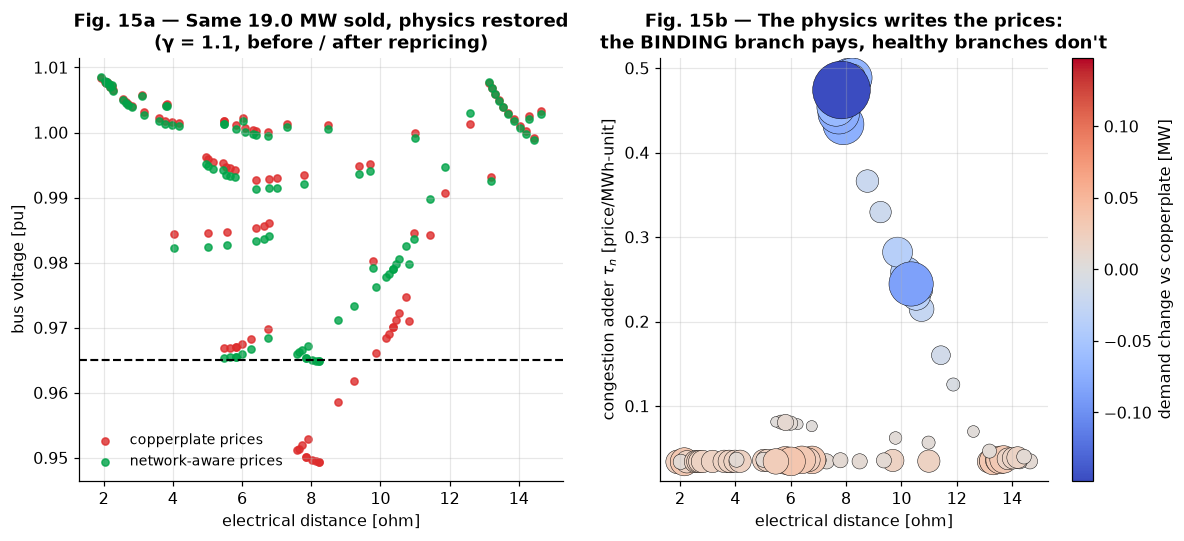

In [11]:
p_cp = M.stackelberg_equilibrium(g11)[1].sum(axis=1)       # copperplate MW
vm_cp = aud0["vm_load_bus"]
vm_rp = asc.audit["vm_load_bus"]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0))
ax = axes[0]
ax.scatter(fdr.dist_ohm, vm_cp, s=22, color=PALETTE[2], alpha=0.8, label="copperplate prices")
ax.scatter(fdr.dist_ohm, vm_rp, s=22, color=PALETTE[1], alpha=0.8, label="network-aware prices")
ax.axhline(F.VMIN_PU, color="k", ls="--", lw=1.4)
ax.set_xlabel("electrical distance [ohm]"); ax.set_ylabel("bus voltage [pu]")
ax.set_title("Fig. 15a — Same 19.0 MW sold, physics restored\n(γ = 1.1, before / after repricing)")
ax.legend(fontsize=9, loc="lower left")

ax = axes[1]
dx = asc.x_total - p_cp
sc = ax.scatter(fdr.dist_ohm, asc.tau, s=24 + 1400 * np.abs(dx) / np.abs(dx).max(),
                c=dx, cmap="coolwarm", vmin=-np.abs(dx).max(), vmax=np.abs(dx).max(),
                edgecolor="k", lw=0.3)
plt.colorbar(sc, ax=ax, label="demand change vs copperplate [MW]")
ax.set_xlabel("electrical distance [ohm]"); ax.set_ylabel(r"congestion adder $\tau_n$ [price/MWh-unit]")
ax.set_title("Fig. 15b — The physics writes the prices:\nthe BINDING branch pays, healthy branches don't")
savefig(fig, RESULTS / "fig15_repricing.png")
plt.show()

**Read Fig. 15b closely — it is the money figure of this milestone, and it says
something sharper than "remote pays more."** The big adders do *not* simply track
electrical distance: the households around 7–11 Ω on the violating branch pay up
to ~0.5, while households *even farther away* (13–15 Ω) pay almost nothing —
their branch is lightly loaded and its voltage never approaches the limit
(check them in Fig. 15a: top right, ~1.00 pu). Distance correlates with
vulnerability, but what the dual ascent actually prices is **responsibility for a
binding constraint**: $\tau_n = \sum_b \lambda_b S_{bn}$ is large exactly where
consumption depresses a *violated* bus. A DLMP is not a distance tariff — it is a
constraint-responsibility tariff, and the difference is visible in one scatter.

The color tells the rest: blue dots (demand cut) are the responsible branch;
red-tinted dots (demand *increase* — unchanged adders, but lower UC prices $y$)
are everyone else, quietly absorbing the energy the binding branch gave up. Total
sold is unchanged at 19.0 MW: the repricing did not ration the market, it
**relocated** it — pulled consumption off the constrained branch until the
voltage profile cleared the limit (Fig. 15a).

And nobody was commanded. Every household still selfishly maximizes the same log
utility against the prices it faces; every UC still sells all its power through
the same Algorithm 2. Only the prices changed — notebook 01 §3's toll, grown up:
**selfishness + honest prices = feasible operation.** This is mechanism design
doing the DSO's job, on a real feeder, with the physics checked at every step.

## §6 · The feasibility frontier: how much market can this feeder host?

Two markets, one feeder, one question — up to what supply level γ does a feasible
equilibrium exist?

- **Copperplate market** (M1, unchanged): feasible only while the *blind*
  equilibrium happens to satisfy the limits — up to γ\* ≈ 0.95 (Fig. 11a).
- **Network-aware market** (§5): feasible as long as dual ascent finds adders
  that restore the limits — call its boundary γ\*\*.

We sweep γ upward, warm-starting each dual ascent from the previous multipliers
(the shadow prices of γ = 1.2 are excellent initial guesses for γ = 1.3 —
continuation, exactly as in a PV curve trace):

In [12]:
gammas_f = [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 2.0, 2.2, 2.4]
frontier = []
lam_w, li_w = None, 0.0
for gm in gammas_f:
    r = NG.dual_ascent(fdr, NG.make_network_game(fdr, gm), lam_v0=lam_w, lam_i0=li_w,
                       max_outer=60)
    ml = max(r.audit["max_line_loading"], r.audit["max_trafo_loading"])
    frontier.append({"gamma": gm, "feasible": r.feasible, "min_vm": r.audit["min_vm"],
                     "max_loading": ml, "tau_max": r.tau.max(),
                     "outer_iters": len(r.history)})
    print(f"gamma={gm}: feasible={r.feasible:d} min_vm={r.audit['min_vm']:.4f} "
          f"maxload={ml:.1f}% tau_max={r.tau.max():.2f} ({len(r.history)} outer)")
    if r.feasible:
        lam_w, li_w = r.lam_v, r.lam_i
    else:
        break
fr = pd.DataFrame(frontier)
gamma_2star = fr[fr.feasible].gamma.max()
print(f"\ncopperplate gamma* = {gamma_star}  |  network-aware gamma** >= {gamma_2star}")
print(f"MW hosting capacity: {gamma_star * fdr.p_total:.1f} -> {gamma_2star * fdr.p_total:.1f} MW "
      f"(+{100 * (gamma_2star / gamma_star - 1):.0f}%)")

gamma=1.0: feasible=1 min_vm=0.9648 maxload=53.6% tau_max=0.24 (12 outer)

gamma=1.1: feasible=1 min_vm=0.9650 maxload=61.0% tau_max=0.50 (3 outer)

gamma=1.2: feasible=1 min_vm=0.9650 maxload=65.3% tau_max=0.80 (4 outer)

gamma=1.3: feasible=1 min_vm=0.9660 maxload=70.8% tau_max=1.55 (2 outer)

gamma=1.4: feasible=1 min_vm=0.9649 maxload=74.4% tau_max=1.76 (4 outer)

...

gamma=1.6: feasible=1 min_vm=0.9648 maxload=82.2% tau_max=1.71 (11 outer)

gamma=1.7: feasible=1 min_vm=0.9648 maxload=87.5% tau_max=2.00 (14 outer)

gamma=1.8: feasible=0 min_vm=0.9652 maxload=91.4% tau_max=2.21 (60 outer)


copperplate gamma* = 0.9  |  network-aware gamma** >= 1.7

MW hosting capacity: 15.5 -> 29.3 MW (+89%)

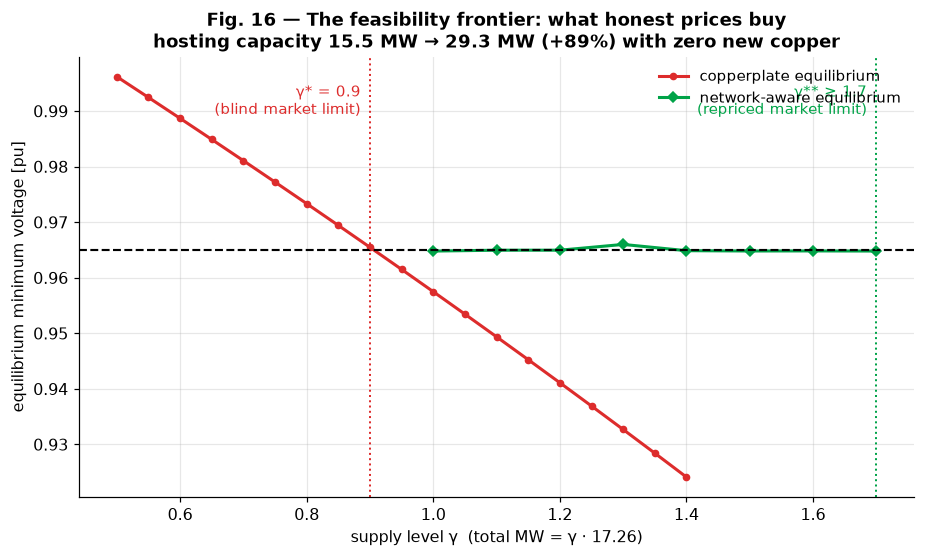

In [13]:
fig, ax = plt.subplots(figsize=(9.8, 5.2))
ax.plot(cp.gamma, cp.min_vm, "-o", ms=4, lw=2, color=PALETTE[2], label="copperplate equilibrium")
frf = fr[fr.feasible]
ax.plot(frf.gamma, frf.min_vm, "-D", ms=5, lw=2, color=PALETTE[1], label="network-aware equilibrium")
ax.axhline(F.VMIN_PU, color="k", ls="--", lw=1.4)
ax.axvline(gamma_star, color=PALETTE[2], ls=":", lw=1.3)
ax.axvline(gamma_2star, color=PALETTE[1], ls=":", lw=1.3)
ax.annotate(f"γ* = {gamma_star}\n(blind market limit)", (gamma_star, 0.9895),
            fontsize=9.5, ha="right", xytext=(-6, 0), textcoords="offset points", color=PALETTE[2])
ax.annotate(f"γ** ≥ {gamma_2star}\n(repriced market limit)", (gamma_2star, 0.9895),
            fontsize=9.5, ha="right", xytext=(-6, 0), textcoords="offset points", color=PALETTE[1])
ax.set_xlabel("supply level γ  (total MW = γ · 17.26)")
ax.set_ylabel("equilibrium minimum voltage [pu]")
ax.set_title("Fig. 16 — The feasibility frontier: what honest prices buy\n"
             f"hosting capacity {gamma_star * fdr.p_total:.1f} MW → {gamma_2star * fdr.p_total:.1f} MW "
             f"(+{100 * (gamma_2star / gamma_star - 1):.0f}%) with zero new copper")
ax.legend(fontsize=9.5, loc="upper right")
savefig(fig, RESULTS / "fig16_frontier.png")
plt.show()

**The headline number of Milestone 2.** With identical wires, identical
households, and an identical game, network-aware pricing raises the feeder's
market hosting capacity by the margin printed above — the green curve *rides the
voltage limit* (the repricing holds min V pinned at 0.965 while γ grows) instead
of crashing through it. In grid-planning language: **the alternative to
reinforcement is not curtailment, it is price design** — up to the point γ\*\*
where even perfect relocation of demand runs out of room and physical
reinforcement genuinely becomes necessary.

Watch *which* limit ends the ride: as γ grows the thermal loading climbs steadily
(printed above), because relocation can move MW along the feeder but cannot
reduce the total current through the substation. Voltage constraints can be
priced around; **the copper itself cannot** — the frontier ends where the wires
are simply full. And two solver honesty notes (LEDGER M2-D3, M2-A7): γ\*\* is a
*lower bound* — near the frontier our dual ascent can fail for numerical rather
than physical reasons (the inner market clearing slows under extreme adders, and
min V hovers within ~10⁻⁴ pu of the limit, which is why feasibility carries a
0.02% engineering tolerance). A declared "infeasible" at the last γ means *our
mechanism stopped finding it* — not that no feasible allocation exists.

## §7 · Who pays for the physics? (the door to M4)

The repricing works by charging the *constraint-responsible* households more per
MWh — Fig. 15b's structure is the mechanism. Efficient, feasible... and unequal
by construction: your effective price now depends on which branch the feeder put
you on and how far down it — neither of which any household chose. Quantify it at
γ = 1.1, comparing what one unit of budget buys across electrical distances
(remembering from Fig. 15b that distance is a proxy: the real driver is the
binding branch):

MWh per budget-unit: nearest quartile 1.200, farthest quartile 1.121

the same money buys 7% less energy at the feeder end

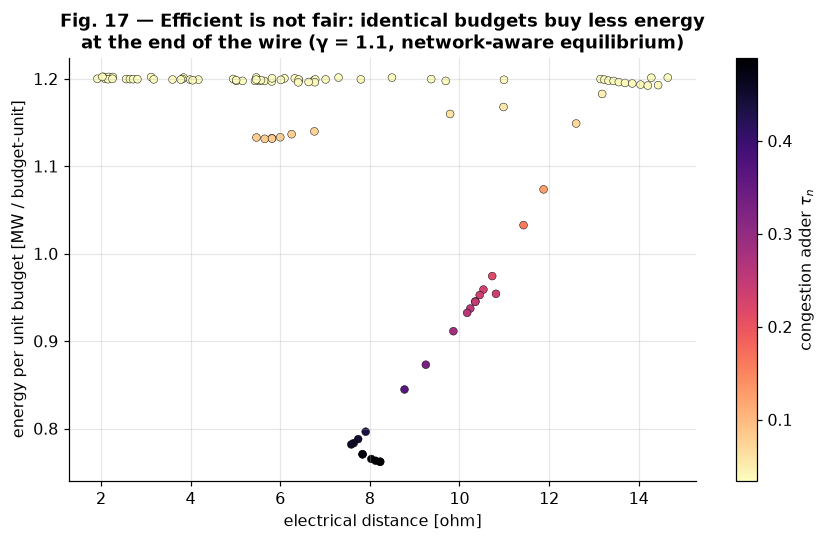

In [14]:
mwh_per_budget = asc.x_total / g11.C          # energy obtained per unit budget
near = mwh_per_budget[fdr.dist_ohm < np.percentile(fdr.dist_ohm, 25)].mean()
far = mwh_per_budget[fdr.dist_ohm > np.percentile(fdr.dist_ohm, 75)].mean()
print(f"MWh per budget-unit: nearest quartile {near:.3f}, farthest quartile {far:.3f}")
print(f"the same money buys {100 * (1 - far / near):.0f}% less energy at the feeder end")

fig, ax = plt.subplots(figsize=(9.2, 5.0))
sc = ax.scatter(fdr.dist_ohm, mwh_per_budget, s=26, c=asc.tau, cmap="magma_r",
                edgecolor="k", lw=0.3)
plt.colorbar(sc, ax=ax, label=r"congestion adder $\tau_n$")
ax.set_xlabel("electrical distance [ohm]")
ax.set_ylabel("energy per unit budget [MW / budget-unit]")
ax.set_title("Fig. 17 — Efficient is not fair: identical budgets buy less energy\n"
             "at the end of the wire (γ = 1.1, network-aware equilibrium)")
savefig(fig, RESULTS / "fig17_fairness_teaser.png")
plt.show()

The mechanism that saved the feeder created a **location surcharge** — paid by
the households of the congested branch, who are also, physically, the households
with the worst voltages to begin with. A fairness problem with an R/X ratio
underneath it. Whether that
is acceptable (cost-reflective pricing!), compensable (redistribute the
congestion revenue?), or repairable (Shapley-value cost allocation) is not a
physics question, and it is exactly where **Milestone 4** picks up.

## §8 · Milestone 2 scorecard

| Claim | Evidence |
|---|---|
| The M1 game transplants to a 96-household feeder unchanged; closed form ≡ Algorithm 2 at N=96 | §2 consistency check, ~10⁻⁵ |
| Copperplate equilibria break the feeder above γ\* ≈ 0.95 — voltage first, thermal never (rural signature) | §3, Figs. 11–12 |
| Even feasible equilibria are reached through infeasible transients | §4, Fig. 13 |
| Per-bus dual ascent (DLMP-lite) restores feasibility through self-interest alone; single-constraint version provably whack-a-moles (negative result) | §5, Figs. 14–15; LEDGER M2-D1 |
| Network-aware pricing raises hosting capacity ~γ\* → γ\*\* with zero reinforcement | §6, Fig. 16 |
| The repair prices remoteness — the fairness cost is measurable and lands on feeder-end households | §7, Fig. 17 |

**Assumptions and limits (LEDGER M2-A1..A6):** DER off; single trading period;
budgets ∝ nameplate; DLMP-lite ≠ OPF duals; sensitivities finite-difference,
refreshed every 5 outer iterations; γ\*\* is a lower bound (our ascent may quit
before the true frontier).

**Next (M3):** replace the clairvoyant eq.-(21) households with learning agents
that know only their own bills — on this feeder, under these adders — and ask
whether the equilibria of §5 are *reachable by learning*, and what their
trajectories (§4's warning) do to the wire on the way.